# 16 — 数式変更Capstone

上流コードを触る前に、変更したい仮定・式・テスト・比較指標を一つの変更票にします。

**前提**: `15_tuning_laboratory.ipynb`

> 読み方: 「直感 → 数式 → 上流コード → 小実験 → 解釈」の順です。
> `実装事実` と書いた箇所は現行 `external/Quadruped-PyMPC` のコード、
> `学習用モデル` は理解のために単純化した再実装です。

In [1]:
# 背景: 数式変更Capstoneを上流PyMPCと同じリポジトリ配置・環境変数で検討します。
# 目的: ワークスペースとPyMPCの場所を確定し、後続セルの実行条件を再現可能にします。
# OSに依存しないパス演算を行うためPathを読み込む。
from pathlib import Path
# 環境変数の設定にos、モジュール検索パスの設定にsysを使う。
import os, sys

# Notebookを起動した現在位置を絶対パスへ正規化する。
ROOT = Path.cwd().resolve()
# notebook_pympc直下から起動した場合だけリポジトリルートへ移る。
if ROOT.name == "notebook_pympc":
    # 外部実装をROOT基準で参照できるよう親ディレクトリを採用する。
    ROOT = ROOT.parent
# 上流Quadruped-PyMPCの配置先をROOTから組み立てる。
PYMPC_ROOT = ROOT / "external" / "Quadruped-PyMPC"
# 誤った起動場所のまま実験を進めないよう実装の存在を検証する。
assert PYMPC_ROOT.exists(), f"Quadruped-PyMPC が見つかりません: {PYMPC_ROOT}"
# 同名モジュールの取り違えを防ぐため検索パス未登録時だけ処理する。
if str(PYMPC_ROOT) not in sys.path:
    # 現行リポジトリの実装を最優先でimportするため先頭へ追加する。
    sys.path.insert(0, str(PYMPC_ROOT))

# acados生成物の探索基準を未設定時だけ上流同梱ディレクトリへ合わせる。
os.environ.setdefault("ACADOS_SOURCE_DIR", str(PYMPC_ROOT / "quadruped_pympc" / "acados"))
# 画面のない環境でもMuJoCoを描画できるよう未設定時はEGLを選ぶ。
os.environ.setdefault("MUJOCO_GL", "egl")
# 実験が参照するワークスペースを目視確認できるよう表示する。
print("workspace :", ROOT)
# 上流実装の参照先を目視確認できるよう表示する。
print("PyMPC root:", PYMPC_ROOT)

workspace : /home/takuya/work/mpc_dog
PyMPC root: /home/takuya/work/mpc_dog/external/Quadruped-PyMPC


## 例: 異方性摩擦

現行はx/yで同じ \(\mu\) を使います。異方性地面を研究するなら候補式は

\[
|F_x|\le\mu_xF_z,\qquad |F_y|\le\mu_yF_z
\]

です。変更箇所は制約式だけでなく、設定値、runtime parameter、可視化、
feasibility test、baseline比較まで及びます。

In [2]:
# 背景: 現行の等方摩擦制約はx/y方向に同じμを使い、異方性地面を表現できません。
# 目的: 等方式とμx・μyを分けた候補式を既知の3つのworld座標GRFで比較します。
# 1脚の床反力ベクトル [Fx,Fy,Fz] を扱うためNumPyを使う。
import numpy as np
# 等方摩擦角錐 |Fx|≤μFz, |Fy|≤μFz, Fz≥0 の実行可能性を返す。
def isotropic(force, mu):
    # force、shape (3,) をworld座標のFx,Fy,Fz [N]へ分解する。
    fx, fy, fz = force
    # x/yで同じμを使う3制約をすべて満たす場合だけTrueを返す。
    return abs(fx) <= mu*fz and abs(fy) <= mu*fz and fz >= 0
# 異方性摩擦角錐 |Fx|≤μxFz, |Fy|≤μyFz, Fz≥0 の実行可能性を返す。
def anisotropic(force, mu_x, mu_y):
    # force、shape (3,) をworld座標のFx,Fy,Fz [N]へ分解する。
    fx, fy, fz = force
    # x/yで別々の摩擦係数を使う3制約をすべて満たす場合だけTrueを返す。
    return abs(fx) <= mu_x*fz and abs(fy) <= mu_y*fz and fz >= 0

# x優勢、y優勢、x/y同大の3つの既知GRF [N]を用意する。
cases = [
    # 前方Fxが大きく横方向Fyが小さいworld座標GRFを定義する。
    np.array([20., 10., 50.]),
    # 前方Fxが小さく横方向Fyが大きいworld座標GRFを定義する。
    np.array([10., 20., 50.]),
    # 前方・横方向が同じ大きさのworld座標GRFを定義する。
    np.array([20., 20., 50.]),
]
# 3ケースを同じ旧式μ=0.42と新式μx=0.6, μy=0.25で比較する。
for f in cases:
    # force値と旧式・新式の実行可能性を同じ行へ表示する。
    print(f, "old:", isotropic(f, .42), "new:", anisotropic(f, .6, .25))

[20. 10. 50.] old: True new: True
[10. 20. 50.] old: True new: False
[20. 20. 50.] old: True new: False


## 変更票

1. **仮説**: どの現象を既存式が表現できないか
2. **数式差分**: 旧式と新式、単位、domain
3. **コード差分**: model / OCP / config / interfaceの境界
4. **単体テスト**: 既知のfeasible/infeasible点
5. **退行テスト**: \(\mu_x=\mu_y\) なら旧式と一致
6. **閉ループ比較**: 同seed、同指令、同scene
7. **棄却条件**: solver失敗、飽和、計算時間悪化の上限

このNotebookでは候補式だけを試し、上流コードは変更していません。

In [3]:
# 背景: 候補式はμx=μyに戻したとき現行の等方式と一致する退行性が必要です。
# 目的: 10,000個のworld座標GRFで旧式と縮退した新式を比較し、不一致が0件か検証します。
# 再実行時も同じサンプルになるようseed=3の乱数生成器を作る。
rng = np.random.default_rng(3)
# Fx,Fy∈[-30,30] N、Fz∈[0,80] Nからshape (10000,3)のGRF群を生成する。
forces = rng.uniform([-30,-30,0], [30,30,80], size=(10000,3))
# 現行等方式μ=0.42を各GRFへ適用し、shape (10000,)の真偽配列を作る。
old = np.array([isotropic(f,.42) for f in forces])
# 新式をμx=μy=0.42へ縮退させ、同じGRF群の真偽配列を作る。
same = np.array([anisotropic(f,.42,.42) for f in forces])
# 2つの判定配列で異なる要素数を退行テスト結果として表示する。
print("regression mismatches:", np.count_nonzero(old != same))
# 全10,000件が完全一致しなければ候補式の退行性違反として停止する。
assert np.array_equal(old, same)

regression mismatches: 0


## 修了判定

`simulation.py` の観測から `compute_actions`、WB参照、MPC、GRF、
stance/swing torque、MuJoCo stepまでをshape・単位・frame付きで説明でき、
1パラメータ変更をログで評価し、上の変更票を埋められれば修了です。

次の研究候補は、input-rate MPC、sampling MPC、foothold optimization、
nonuniform discretization、integral states、RTIの順に、標準nominalとの差分として学びます。

# Repository Performance Benchmark — 30シナリオ長時間実測

## 目的と方法

短時間の数値だけでは転倒の様子を判定できないため、**現行リポジトリのnominal acados NMPC、WBInterface、stance/swing torque、90% torque clip、MuJoCo Go2 plantを実際に閉ループ実行**し、全シナリオで動画と数値を同時に残しました。

- Easy / Normal / Hardを各10条件、合計30条件
- 全条件を前進歩行とし、**20秒以上かつ累積10 m以上**まで実行
- 転倒時はfallを記録してresetし、resilient累積距離を継続
- `strict_success`は10 m達成に加え、fall=0かつ姿勢限界35 deg以内
- GIFは8 fps相当、follow camera、時刻・距離・fall数をoverlay
- `type='nominal'`, `N=12`, `dt_mpc=0.02 s`, MPC 100 Hz
- 各条件は別processで起動し、controller stateや設定値の持越しを防止

結果の正本は`benchmark_results_long/scenario_results.json`、GIFは`benchmark_results_long/gifs/`、再実行コードは`../scripts/run_pympc_long_gif_benchmark.py`です。

In [4]:
# 背景: 30条件の長時間benchmarkはJSONを正本とし、同じデータから表・図・GIF評価文を生成します。
# 目的: scenario定義と実測metricsを30行のDataFrameへ変換し、収録要件を検証します。
# OSに依存しない結果ファイルのパス解決にPathを使う。
from pathlib import Path
# JSON文字列をPythonの辞書・リストへ復元するためjsonを使う。
import json
# 30シナリオを列名付き表として集計するためpandasを使う。
import pandas as pd
# 後続セルの数値配列処理にNumPyを使う。
import numpy as np
# 後続セルでbenchmark指標を可視化するためMatplotlibを使う。
import matplotlib.pyplot as plt

# Notebookをどこから開いても長時間結果JSONを見つける。
# 現在位置を絶対パスへ正規化し、結果探索の基準にする。
HERE = Path.cwd().resolve()
# リポジトリルートから起動した場合だけnotebook_pympcを補う。
if HERE.name != "notebook_pympc":
    # benchmark_results_longの親となるNotebookディレクトリへ移る。
    HERE = HERE / "notebook_pympc"
# 30条件の正本scenario_results.jsonへのパスを組み立てる。
RESULTS = HERE / "benchmark_results_long" / "scenario_results.json"
# UTF-8でJSONを読み、scenarioとmetricsを含むpayloadへ復元する。
payload = json.loads(RESULTS.read_text(encoding="utf-8"))

# scenario定義と20秒/10 m実測metricsを横持ちにして30行へ変換。
# 1シナリオ1行へ変換した辞書を蓄える空リストを作る。
rows = []
# JSONに保存された30件の結果を入力順のまま走査する。
for entry in payload["results"]:
    # scenario条件と実測metricsを同じ行の列へ展開する。
    row = {**entry["scenario"], **entry["metrics"]}
    # 作成した1行をDataFrame化するためリストへ追加する。
    rows.append(row)
# 30個の行辞書を列名付きDataFrameへ変換する。
df = pd.DataFrame(rows)
# Easy/Normal/Hard各10件、合計30件が欠けていないことを検証する。
assert len(df) == 30
# 難易度ごとの件数が各10件であることを検証する。
assert df.groupby("difficulty").size().to_dict() == {"easy": 10, "hard": 10, "normal": 10}
# 全条件がtask_completed判定を満たすことを検証する。
assert df["task_completed"].all()
# 全条件のMuJoCoシミュレーション時間が20 s以上であることを検証する。
assert (df["simulated_s"] >= 20).all()
# reset後を含む全条件の累積平面距離が10 m以上であることを検証する。
assert (df["cumulative_distance_m"] >= 10).all()
# 検証済みの実閉ループシナリオ件数を表示する。
print("loaded:", len(df), "long real closed-loop scenarios")

loaded: 30 long real closed-loop scenarios


## 成功判定と計測量

2種類を分けて判定します。

- **task_completed**: GIF/試験時間が20秒以上、累積平面歩行距離が10 m以上
- **strict_success**: task_completedに加え、fall=0、最大|roll|と|pitch|が35 deg以下

転倒後resetを含む累積10 mは「仕事を完了できた」判定であり、「連続無転倒歩行」とは呼びません。各GIFのoverlayに時刻、累積距離、fall数を表示します。

性能値として速度RMSE、姿勢最大値、torque飽和率、control時間、acados solve時間、実時間倍率、solver statusを保存しています。35 deg閾値は論文の保証値ではなく、この教材内で比較するため事前定義した判定です。

In [5]:
# 背景: task完了と無転倒成功を混同しないため、条件・距離・姿勢・飽和・計算時間を同じ行で見ます。
# 目的: 30シナリオから比較に必要な列だけを順序固定で抽出し、小数3桁の表として表示します。
# 30条件の一覧。20秒、10 m、fall、姿勢、計算時間を同じ行で確認する。
# 条件、成功判定、運動性能、計算性能の順に表示列を定義する。
columns = [
    # シナリオ識別子、難易度、説明、地形、指令前進速度[m/s]を並べる。
    "id", "difficulty", "description", "scene", "vx",
    # task/strict判定とシミュレーション・GIF時間[s]を並べる。
    "task_completed", "strict_success", "simulated_s", "gif_playback_s",
    # 累積距離[m]、転倒数、速度RMSE[m/s]を並べる。
    "cumulative_distance_m", "falls", "speed_rmse_mps",
    # 最大姿勢角[deg]、トルク飽和率、MPC p95時間[ms]を並べる。
    "max_abs_roll_deg", "max_abs_pitch_deg", "torque_saturation_rate",
    # 100 Hzの10 ms予算と比較するMPC solve p95 [ms]を最後に置く。
    "mpc_solve_p95_ms",
]
# 指定列を小数3桁へ丸め、既存benchmark出力と同じ30行の表を表示する。
display(df[columns].round(3))

,id,difficulty,description,scene,vx,task_completed,strict_success,simulated_s,gif_playback_s,cumulative_distance_m,falls,speed_rmse_mps,max_abs_roll_deg,max_abs_pitch_deg,torque_saturation_rate,mpc_solve_p95_ms
0,E01,easy,Flat 0.50 m/s baseline,flat,0.50,True,True,23.178,23.27,10.000,0,0.046,0.737,2.341,0.000,1.893
1,E02,easy,"Flat 0.55 m/s, slow gait",flat,0.55,True,True,21.874,21.97,10.000,0,0.077,0.953,3.418,0.000,2.074
2,E03,easy,"Flat 0.60 m/s, long stance",flat,0.60,True,True,21.076,21.19,10.001,0,0.111,0.693,4.694,0.007,2.193
3,E04,easy,"Flat 0.60 m/s, conservative MPC friction",flat,0.60,True,True,20.442,20.54,10.001,0,0.091,0.753,2.818,0.001,2.094
4,E05,easy,"Flat 0.60 m/s, fixed footholds",flat,0.60,True,True,20.512,20.54,10.000,0,0.093,0.796,2.774,0.000,2.337
5,E06,easy,"Flat 0.55 m/s, physical friction 0.60",flat,0.55,True,True,21.306,21.32,10.000,0,0.051,0.750,2.377,0.000,1.812
6,E07,easy,Flat 0.60 m/s plus gentle yaw,flat,0.60,True,True,20.078,20.15,10.000,0,0.071,0.766,2.806,0.000,1.919
7,E08,easy,"Flat 0.65 m/s, gait 1.20 Hz",flat,0.65,True,True,22.192,22.23,10.001,0,0.220,1.758,7.670,0.016,2.330
8,E09,easy,"Flat 0.60 m/s, lower body reference",flat,0.60,True,True,20.518,20.54,10.001,0,0.095,0.892,6.207,0.001,2.090
9,E10,easy,"Flat 0.70 m/s, high physical friction",flat,0.70,True,True,21.248,21.32,10.000,0,0.253,3.054,7.926,0.024,2.299


In [6]:
# 背景: 個別30行だけでは難易度上昇に伴う成功率・転倒・追従・計算負荷の傾向を読み取りにくくなります。
# 目的: Easy→Normal→Hardの順で件数・合計・平均を集約し、strict成功率を計算します。
# 難易度別にtask完了率、無転倒成功率、fall、追従、計算時間を集約する。
# 集約表を教材の難易度順へ固定するためカテゴリ順を定義する。
order = ["easy", "normal", "hard"]
# difficultyごとに離散件数・合計値・連続量平均を集約する。
summary = df.groupby("difficulty").agg(
    # 各難易度のシナリオ数をidの件数として数える。
    scenarios=("id", "count"),
    # task_completed=Trueを1として合計し、task完了件数を得る。
    task_completed=("task_completed", "sum"),
    # strict_success=Trueを1として合計し、無転倒・姿勢内成功件数を得る。
    strict_successes=("strict_success", "sum"),
    # 転倒回数を難易度内で合計する。
    total_falls=("falls", "sum"),
    # 各試験のMuJoCo時間[s]を難易度内で平均する。
    mean_duration_s=("simulated_s", "mean"),
    # 前進速度RMSE[m/s]を難易度内で平均する。
    mean_speed_rmse_mps=("speed_rmse_mps", "mean"),
    # 全関節・全周期のトルク飽和率を難易度内で平均する。
    mean_torque_saturation=("torque_saturation_rate", "mean"),
    # 各シナリオのMPC solve p95[ms]を難易度内で平均する。
    mean_mpc_p95_ms=("mpc_solve_p95_ms", "mean"),
# groupbyの既定順ではなくEasy→Normal→Hardへ行順を並べ直す。
).reindex(order)
# strict成功件数をシナリオ数で割り、難易度別成功率[0,1]を追加する。
summary["strict_success_rate"] = summary["strict_successes"] / summary["scenarios"]
# 集約値を小数3桁へ丸め、既存benchmark出力と同じ表を表示する。
display(summary.round(3))

,scenarios,task_completed,strict_successes,total_falls,mean_duration_s,mean_speed_rmse_mps,mean_torque_saturation,mean_mpc_p95_ms,strict_success_rate
difficulty,,,,,,,,,
easy,10,10,10,0,21.242,0.111,0.005,2.104,1.0
normal,10,10,6,13,25.911,0.266,0.014,2.188,0.6
hard,10,10,2,23,29.394,0.537,0.032,2.631,0.2


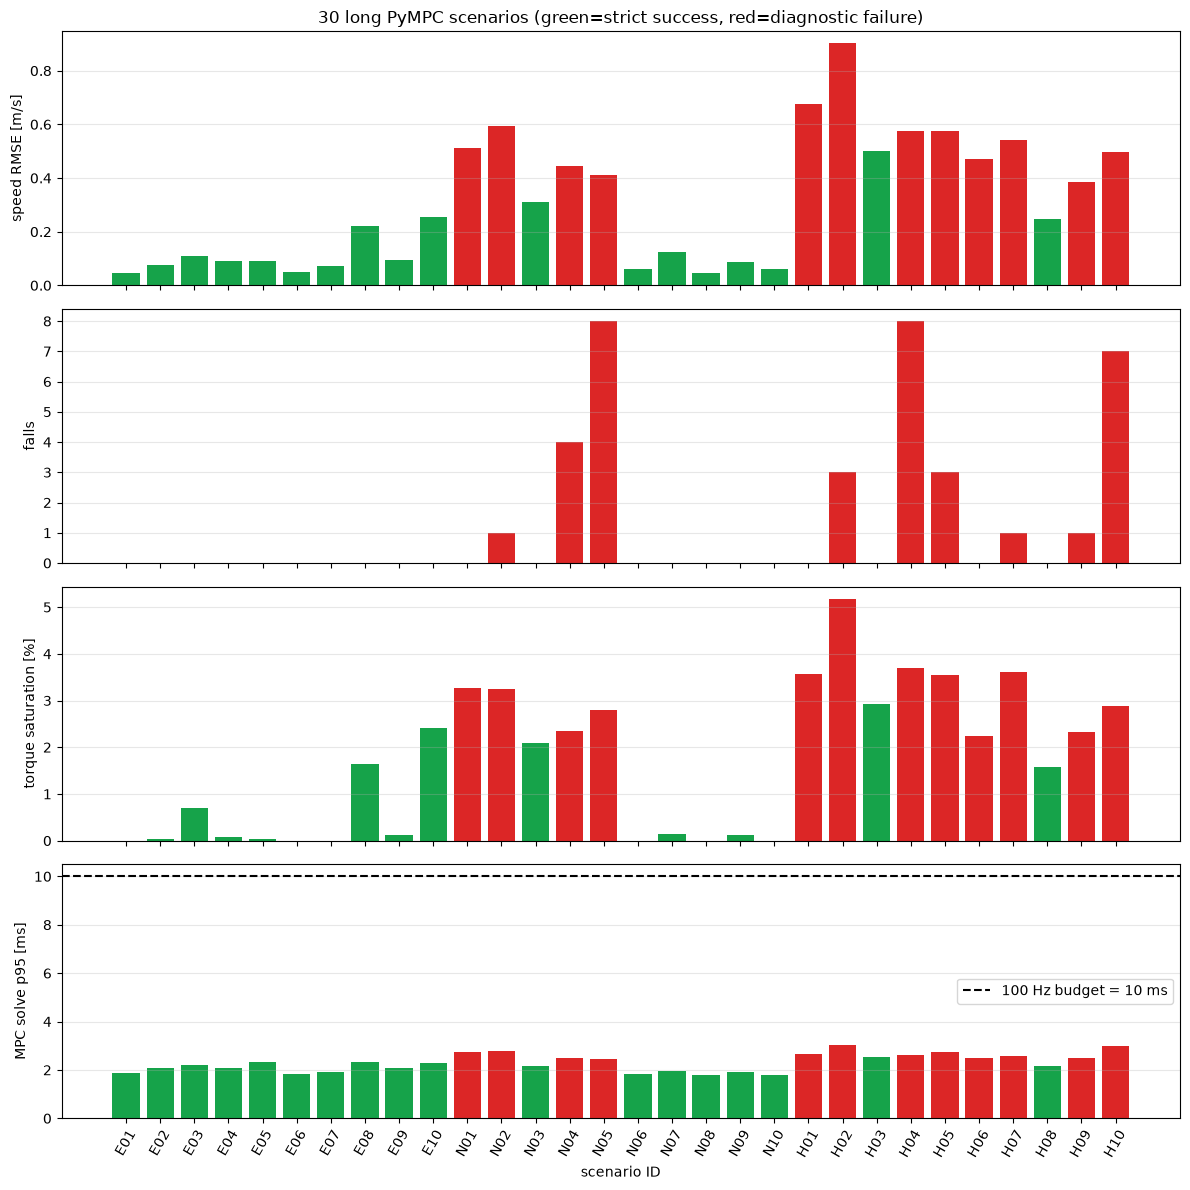

In [7]:
# 背景: strict成否と速度誤差・転倒・トルク飽和・MPC時間の対応を同じシナリオ軸で比較します。
# 目的: 30条件を4段の棒グラフに描き、成功を緑、診断失敗を赤、10 ms予算を破線で示します。
# 緑=無転倒・姿勢限界内、赤=taskは完了したがstrict失敗。
# strict_success真偽値を各シナリオの棒色へ写像する。
colors = df["strict_success"].map({True: "#16a34a", False: "#dc2626"})
# 共通のscenario ID横軸を持つ4行1列、12 inch四方の図を作る。
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
# 第1段へ前進速度RMSE [m/s]をシナリオ別に描く。
axes[0].bar(df["id"], df["speed_rmse_mps"], color=colors)
# 第1段の縦軸へ速度誤差の単位m/sを明記する。
axes[0].set_ylabel("speed RMSE [m/s]")
# 色の意味を含む30条件benchmarkの題名を付ける。
axes[0].set_title("30 long PyMPC scenarios (green=strict success, red=diagnostic failure)")
# 第2段へreset判定された転倒回数を描く。
axes[1].bar(df["id"], df["falls"], color=colors)
# 第2段の縦軸が転倒回数であることを明記する。
axes[1].set_ylabel("falls")
# 第3段へ比率[0,1]を100倍したトルク飽和率[%]を描く。
axes[2].bar(df["id"], df["torque_saturation_rate"]*100, color=colors)
# 第3段の縦軸へ飽和率の単位%を明記する。
axes[2].set_ylabel("torque saturation [%]")
# 第4段へacados MPC solve時間の95 percentile [ms]を描く。
axes[3].bar(df["id"], df["mpc_solve_p95_ms"], color=colors)
# 100 Hz周期に対応する10 ms計算予算を黒破線で示す。
axes[3].axhline(10.0, color="k", ls="--", label="100 Hz budget = 10 ms")
# 第4段の縦軸へsolve時間の単位msを明記する。
axes[3].set_ylabel("MPC solve p95 [ms]")
# 共通横軸がシナリオ識別子であることを明記する。
axes[3].set_xlabel("scenario ID")
# 10 ms予算線を識別できるよう第4段へ凡例を表示する。
axes[3].legend()
# 4つの軸すべてへ横方向の値を読みやすくする格子線を加える。
for ax in axes:
    # 棒を邪魔しない透明度0.3でy方向の格子だけを描く。
    ax.grid(axis="y", alpha=0.3)
# 30個のscenario IDが重ならないよう横軸ラベルを60度回転する。
plt.xticks(rotation=60)
# 軸ラベルや題名が重ならないよう余白を自動調整する。
plt.tight_layout()
# 作成した4段のbenchmark図をNotebookへ出力する。
plt.show()

## 実測から得られた結論

- **収録要件: 30/30完了**。全GIFが20秒以上、全試験が累積10 m以上です。ただしreset後の距離も累積するため、これは連続歩行成功率ではありません。
- **Easy: strict 10/10、fall 0**。0.50–0.70 m/sの平地条件はすべて無転倒で、姿勢限界内でした。
- **Normal: strict 6/10、fall合計13**。Perlin、bumpy flat、平地低摩擦は成功しました。0.8–0.9 m/s平地は姿勢限界を超え、random boxesは4回/8回転倒しました。
- **Hard: strict 2/10、fall合計20**。成功はyaw併用平地H03とbumpy uphill H08です。1.0–1.2 m/s、random boxes、強いPerlin/凸凹では姿勢悪化または転倒しました。
- 全条件のMPC solve p95は約1.78–3.02 msで100 Hzの10 ms予算内です。失敗は計算時間超過より、速度・地形・摩擦に対する姿勢悪化とtorque飽和に対応します。
- solver status 2は標準設定のSQP反復上限1による最大反復到達です。上流実装はstatus 1/4のみfallbackし、status 2のiterateを使うため、短いsolve時間を数値的完全収束と解釈してはいけません。

**性能に関する結論:** 現行baselineの実用的な安定域は、この単一seed試験では平地0.7 m/s程度までと、保守的なPerlin/小凸凹です。高速化、random boxes、低摩擦との複合条件では無転倒余裕が急減します。次の変更候補はgait/foothold、torque飽和、接触推定、SQP反復数です。

## 限界と再実行

この結果はGo2 MuJoCo、seed固定、nominal controller、各条件20–42秒の結果です。実機性能、統計的成功確率、sampling MPCとの優劣を直接示しません。fall時にresetして10 mまで継続するため、`task_completed=True`だけを安定歩行の証拠にしてはいけません。下のGIFと`strict_success`を合わせて判断します。

custom bumpy地形は教材側のterrain登録を使います。また実行環境にGNU makeが無いため、配布済みacados shared objectを再利用しました。OCP・solver呼出し・制御ループは上流実装そのものですが、数式を変更した場合はsolverを再buildできる環境が必要です。

30条件を再実行するコマンド:

```bash
set -a && source .env.workshop && set +a
.venv/bin/python scripts/run_pympc_long_gif_benchmark.py
```

比較を研究結果として扱う場合は各条件を複数seedで実行し、Wilson区間などの成功率信頼区間、最初の転倒までの時間、連続無転倒距離も報告してください。

In [8]:
# 背景: 30条件の数値だけでなく、転倒や姿勢崩れを各GIFと同じ場所で照合する必要があります。
# 目的: JSONの順序と値を保ったまま評価文と全30 GIFリンクをMarkdownとして生成・表示します。
# 生成したMarkdownをNotebook上で描画するためMarkdownとdisplayを読み込む。
from IPython.display import Markdown, display

# JSONから30件の評価文とGIFリンクを生成する。Notebook内では各GIFがその場で再生される。
# 出力先リストを章見出し1個で初期化する。
sections = ["# シナリオ別GIFと評価"]
# 難易度が切り替わった位置だけ小見出しを追加するため直前値を未設定にする。
previous_difficulty = None
# 正本JSONの並び順を保って全30シナリオを走査する。
for entry in payload["results"]:
    # 条件sと実測値mを分離し、以降の参照を明確にする。
    s, m = entry["scenario"], entry["metrics"]
    # Easy/Normal/Hardが前行から切り替わった場合だけ難易度見出しを作る。
    if s["difficulty"] != previous_difficulty:
        # 難易度名と各10条件であることをMarkdown見出しへ追加する。
        sections.append(f"## {s['difficulty'].title()} — 10 scenarios")
        # 次の反復で切替を判定できるよう現在の難易度を保存する。
        previous_difficulty = s["difficulty"]

    # 無転倒かつroll/pitch 35 deg以内ならstrict成功文を選ぶ。
    if m["strict_success"]:
        # strict成功が10 m完了を含むことを明示する。
        verdict = "PASS: 10 mを無転倒かつ姿勢限界内で完了"
    # strict失敗かつ転倒回数が正なら転倒による診断失敗文を選ぶ。
    elif m["falls"] > 0:
        # 実測転倒回数を埋め込み、task完了と無転倒成功を区別する。
        verdict = f"DIAGNOSTIC FAIL: 10 mは完了したが{m['falls']}回転倒"
    # 転倒0でも姿勢閾値を超えた残りのstrict失敗を扱う。
    else:
        # roll/pitch 35 deg超過が失敗理由であることを明示する。
        verdict = "DIAGNOSTIC FAIL: 無転倒だがroll/pitchが35 degを超過"

    # 1条件分の見出し・判定・実測値・GIFリンクを1つのMarkdown文字列として追加する。
    sections.append(
        # シナリオIDと説明を3段見出しにする。
        f"### {s['id']} — {s['description']}\n"
        # PASSまたはDIAGNOSTIC FAILを太字で表示する。
        f"**{verdict}**  \n"
        # 地形名と指令world前進速度vx [m/s]を記載する。
        f"scene=`{s['scene']}`, command vx={s['vx']:.2f} m/s, "
        # MuJoCo時間とGIF再生時間を秒単位で記載する。
        f"simulation={m['simulated_s']:.1f} s, GIF={m['gif_playback_s']:.1f} s, "
        # reset後を含む累積平面距離[m]と転倒回数を記載する。
        f"distance={m['cumulative_distance_m']:.2f} m, falls={m['falls']}, "
        # world前進速度のRMSE [m/s]を記載する。
        f"speed RMSE={m['speed_rmse_mps']:.3f} m/s, "
        # world姿勢roll/pitchの最大絶対値[deg]を記載する。
        f"max roll/pitch={m['max_abs_roll_deg']:.1f}/{m['max_abs_pitch_deg']:.1f} deg, "
        # acados solve時間の95 percentile [ms]を記載する。
        f"MPC p95={m['mpc_solve_p95_ms']:.2f} ms.\n\n"
        # JSONのgif_pathをそのまま使い、該当GIFを埋め込む。
        f"![{s['id']} {s['description']}]({m['gif_path']})"
    )

# セクション間を空行2つで結合し、全30 GIFを含むMarkdownを表示する。
display(Markdown("\n\n".join(sections)))

# シナリオ別GIFと評価

## Easy — 10 scenarios

### E01 — Flat 0.50 m/s baseline
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.50 m/s, simulation=23.2 s, GIF=23.3 s, distance=10.00 m, falls=0, speed RMSE=0.046 m/s, max roll/pitch=0.7/2.3 deg, MPC p95=1.89 ms.

![E01 Flat 0.50 m/s baseline](benchmark_results_long/gifs/E01.gif)

### E02 — Flat 0.55 m/s, slow gait
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.55 m/s, simulation=21.9 s, GIF=22.0 s, distance=10.00 m, falls=0, speed RMSE=0.077 m/s, max roll/pitch=1.0/3.4 deg, MPC p95=2.07 ms.

![E02 Flat 0.55 m/s, slow gait](benchmark_results_long/gifs/E02.gif)

### E03 — Flat 0.60 m/s, long stance
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.60 m/s, simulation=21.1 s, GIF=21.2 s, distance=10.00 m, falls=0, speed RMSE=0.111 m/s, max roll/pitch=0.7/4.7 deg, MPC p95=2.19 ms.

![E03 Flat 0.60 m/s, long stance](benchmark_results_long/gifs/E03.gif)

### E04 — Flat 0.60 m/s, conservative MPC friction
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.60 m/s, simulation=20.4 s, GIF=20.5 s, distance=10.00 m, falls=0, speed RMSE=0.091 m/s, max roll/pitch=0.8/2.8 deg, MPC p95=2.09 ms.

![E04 Flat 0.60 m/s, conservative MPC friction](benchmark_results_long/gifs/E04.gif)

### E05 — Flat 0.60 m/s, fixed footholds
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.60 m/s, simulation=20.5 s, GIF=20.5 s, distance=10.00 m, falls=0, speed RMSE=0.093 m/s, max roll/pitch=0.8/2.8 deg, MPC p95=2.34 ms.

![E05 Flat 0.60 m/s, fixed footholds](benchmark_results_long/gifs/E05.gif)

### E06 — Flat 0.55 m/s, physical friction 0.60
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.55 m/s, simulation=21.3 s, GIF=21.3 s, distance=10.00 m, falls=0, speed RMSE=0.051 m/s, max roll/pitch=0.7/2.4 deg, MPC p95=1.81 ms.

![E06 Flat 0.55 m/s, physical friction 0.60](benchmark_results_long/gifs/E06.gif)

### E07 — Flat 0.60 m/s plus gentle yaw
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.60 m/s, simulation=20.1 s, GIF=20.1 s, distance=10.00 m, falls=0, speed RMSE=0.071 m/s, max roll/pitch=0.8/2.8 deg, MPC p95=1.92 ms.

![E07 Flat 0.60 m/s plus gentle yaw](benchmark_results_long/gifs/E07.gif)

### E08 — Flat 0.65 m/s, gait 1.20 Hz
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.65 m/s, simulation=22.2 s, GIF=22.2 s, distance=10.00 m, falls=0, speed RMSE=0.220 m/s, max roll/pitch=1.8/7.7 deg, MPC p95=2.33 ms.

![E08 Flat 0.65 m/s, gait 1.20 Hz](benchmark_results_long/gifs/E08.gif)

### E09 — Flat 0.60 m/s, lower body reference
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.60 m/s, simulation=20.5 s, GIF=20.5 s, distance=10.00 m, falls=0, speed RMSE=0.095 m/s, max roll/pitch=0.9/6.2 deg, MPC p95=2.09 ms.

![E09 Flat 0.60 m/s, lower body reference](benchmark_results_long/gifs/E09.gif)

### E10 — Flat 0.70 m/s, high physical friction
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.70 m/s, simulation=21.2 s, GIF=21.3 s, distance=10.00 m, falls=0, speed RMSE=0.253 m/s, max roll/pitch=3.1/7.9 deg, MPC p95=2.30 ms.

![E10 Flat 0.70 m/s, high physical friction](benchmark_results_long/gifs/E10.gif)

## Normal — 10 scenarios

### N01 — Flat 0.80 m/s
**DIAGNOSTIC FAIL: 無転倒だがroll/pitchが35 degを超過**  
scene=`flat`, command vx=0.80 m/s, simulation=25.4 s, GIF=25.5 s, distance=10.00 m, falls=0, speed RMSE=0.510 m/s, max roll/pitch=35.4/25.2 deg, MPC p95=2.75 ms.

![N01 Flat 0.80 m/s](benchmark_results_long/gifs/N01.gif)

### N02 — Flat 0.90 m/s
**DIAGNOSTIC FAIL: 10 mは完了したが1回転倒**  
scene=`flat`, command vx=0.90 m/s, simulation=24.8 s, GIF=24.8 s, distance=10.00 m, falls=1, speed RMSE=0.596 m/s, max roll/pitch=39.7/21.5 deg, MPC p95=2.78 ms.

![N02 Flat 0.90 m/s](benchmark_results_long/gifs/N02.gif)

### N03 — Flat 0.70 m/s plus yaw 0.25
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.70 m/s, simulation=23.0 s, GIF=23.0 s, distance=10.00 m, falls=0, speed RMSE=0.311 m/s, max roll/pitch=6.8/23.4 deg, MPC p95=2.17 ms.

![N03 Flat 0.70 m/s plus yaw 0.25](benchmark_results_long/gifs/N03.gif)

### N04 — Random boxes 0.50 m/s
**DIAGNOSTIC FAIL: 10 mは完了したが4回転倒**  
scene=`random_boxes`, command vx=0.50 m/s, simulation=41.6 s, GIF=41.6 s, distance=10.00 m, falls=4, speed RMSE=0.445 m/s, max roll/pitch=63.7/44.6 deg, MPC p95=2.49 ms.

![N04 Random boxes 0.50 m/s](benchmark_results_long/gifs/N04.gif)

### N05 — Random boxes 0.60 m/s conservative gait
**DIAGNOSTIC FAIL: 10 mは完了したが8回転倒**  
scene=`random_boxes`, command vx=0.60 m/s, simulation=32.4 s, GIF=32.5 s, distance=10.00 m, falls=8, speed RMSE=0.413 m/s, max roll/pitch=151.1/57.4 deg, MPC p95=2.45 ms.

![N05 Random boxes 0.60 m/s conservative gait](benchmark_results_long/gifs/N05.gif)

### N06 — Perlin 0.50 m/s
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`perlin`, command vx=0.50 m/s, simulation=23.6 s, GIF=23.7 s, distance=10.00 m, falls=0, speed RMSE=0.062 m/s, max roll/pitch=3.9/9.6 deg, MPC p95=1.81 ms.

![N06 Perlin 0.50 m/s](benchmark_results_long/gifs/N06.gif)

### N07 — Perlin 0.60 m/s
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`perlin`, command vx=0.60 m/s, simulation=21.3 s, GIF=21.3 s, distance=10.00 m, falls=0, speed RMSE=0.126 m/s, max roll/pitch=4.5/8.9 deg, MPC p95=1.94 ms.

![N07 Perlin 0.60 m/s](benchmark_results_long/gifs/N07.gif)

### N08 — Bumpy flat 0.50 m/s
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`bumpy_flat`, command vx=0.50 m/s, simulation=23.3 s, GIF=23.3 s, distance=10.00 m, falls=0, speed RMSE=0.048 m/s, max roll/pitch=1.1/5.2 deg, MPC p95=1.78 ms.

![N08 Bumpy flat 0.50 m/s](benchmark_results_long/gifs/N08.gif)

### N09 — Flat 0.60 m/s, low friction
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.60 m/s, simulation=20.4 s, GIF=20.4 s, distance=10.00 m, falls=0, speed RMSE=0.088 m/s, max roll/pitch=0.8/2.8 deg, MPC p95=1.93 ms.

![N09 Flat 0.60 m/s, low friction](benchmark_results_long/gifs/N09.gif)

### N10 — Perlin 0.50 m/s plus yaw 0.15
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`perlin`, command vx=0.50 m/s, simulation=23.4 s, GIF=23.5 s, distance=10.00 m, falls=0, speed RMSE=0.059 m/s, max roll/pitch=2.1/9.1 deg, MPC p95=1.79 ms.

![N10 Perlin 0.50 m/s plus yaw 0.15](benchmark_results_long/gifs/N10.gif)

## Hard — 10 scenarios

### H01 — Flat 1.00 m/s
**DIAGNOSTIC FAIL: 無転倒だがroll/pitchが35 degを超過**  
scene=`flat`, command vx=1.00 m/s, simulation=24.9 s, GIF=25.0 s, distance=10.00 m, falls=0, speed RMSE=0.674 m/s, max roll/pitch=51.9/24.2 deg, MPC p95=2.66 ms.

![H01 Flat 1.00 m/s](benchmark_results_long/gifs/H01.gif)

### H02 — Flat 1.20 m/s
**DIAGNOSTIC FAIL: 10 mは完了したが3回転倒**  
scene=`flat`, command vx=1.20 m/s, simulation=25.4 s, GIF=25.5 s, distance=10.00 m, falls=3, speed RMSE=0.902 m/s, max roll/pitch=128.7/60.3 deg, MPC p95=3.02 ms.

![H02 Flat 1.20 m/s](benchmark_results_long/gifs/H02.gif)

### H03 — Flat 0.90 m/s plus yaw 0.40
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`flat`, command vx=0.90 m/s, simulation=23.0 s, GIF=23.0 s, distance=10.00 m, falls=0, speed RMSE=0.500 m/s, max roll/pitch=11.6/26.3 deg, MPC p95=2.53 ms.

![H03 Flat 0.90 m/s plus yaw 0.40](benchmark_results_long/gifs/H03.gif)

### H04 — Random boxes 0.70 m/s
**DIAGNOSTIC FAIL: 10 mは完了したが8回転倒**  
scene=`random_boxes`, command vx=0.70 m/s, simulation=33.8 s, GIF=33.9 s, distance=10.00 m, falls=8, speed RMSE=0.577 m/s, max roll/pitch=82.0/49.3 deg, MPC p95=2.63 ms.

![H04 Random boxes 0.70 m/s](benchmark_results_long/gifs/H04.gif)

### H05 — Perlin 0.80 m/s
**DIAGNOSTIC FAIL: 10 mは完了したが3回転倒**  
scene=`perlin`, command vx=0.80 m/s, simulation=29.0 s, GIF=29.0 s, distance=10.00 m, falls=3, speed RMSE=0.576 m/s, max roll/pitch=102.4/53.4 deg, MPC p95=2.73 ms.

![H05 Perlin 0.80 m/s](benchmark_results_long/gifs/H05.gif)

### H06 — Perlin 0.70 m/s, low friction
**DIAGNOSTIC FAIL: 無転倒だがroll/pitchが35 degを超過**  
scene=`perlin`, command vx=0.70 m/s, simulation=32.7 s, GIF=32.8 s, distance=10.00 m, falls=0, speed RMSE=0.470 m/s, max roll/pitch=42.8/21.6 deg, MPC p95=2.49 ms.

![H06 Perlin 0.70 m/s, low friction](benchmark_results_long/gifs/H06.gif)

### H07 — Bumpy flat 0.80 m/s
**DIAGNOSTIC FAIL: 10 mは完了したが1回転倒**  
scene=`bumpy_flat`, command vx=0.80 m/s, simulation=29.8 s, GIF=29.8 s, distance=10.00 m, falls=1, speed RMSE=0.541 m/s, max roll/pitch=97.0/28.4 deg, MPC p95=2.59 ms.

![H07 Bumpy flat 0.80 m/s](benchmark_results_long/gifs/H07.gif)

### H08 — Bumpy uphill 0.60 m/s
**PASS: 10 mを無転倒かつ姿勢限界内で完了**  
scene=`bumpy_uphill`, command vx=0.60 m/s, simulation=27.5 s, GIF=27.6 s, distance=10.00 m, falls=0, speed RMSE=0.247 m/s, max roll/pitch=5.1/18.1 deg, MPC p95=2.17 ms.

![H08 Bumpy uphill 0.60 m/s](benchmark_results_long/gifs/H08.gif)

### H09 — Bumpy downhill 0.60 m/s
**DIAGNOSTIC FAIL: 10 mは完了したが1回転倒**  
scene=`bumpy_downhill`, command vx=0.60 m/s, simulation=32.5 s, GIF=32.6 s, distance=10.00 m, falls=1, speed RMSE=0.384 m/s, max roll/pitch=77.8/24.2 deg, MPC p95=2.48 ms.

![H09 Bumpy downhill 0.60 m/s](benchmark_results_long/gifs/H09.gif)

### H10 — Random boxes 0.60 m/s, low friction
**DIAGNOSTIC FAIL: 10 mは完了したが7回転倒**  
scene=`random_boxes`, command vx=0.60 m/s, simulation=35.5 s, GIF=35.5 s, distance=10.00 m, falls=7, speed RMSE=0.496 m/s, max roll/pitch=148.7/49.3 deg, MPC p95=3.00 ms.

![H10 Random boxes 0.60 m/s, low friction](benchmark_results_long/gifs/H10.gif)

## 章末チェック

出力を眺めるだけでなく、次を自分の言葉で答えてください。

1. この章の入力・出力の shape、単位、座標系は何か。
2. 変更可能な量と、他の章から渡される量は何か。
3. パラメータを2倍にしたとき、どのグラフがどちらへ変化するか。
4. 現行実装の事実と、学習用の近似を区別できるか。